In [1]:
import hurricane_net as hn
import datetime
import numpy as np
from scipy import stats

In [2]:
data_loader = hn.data()

hurricane_net 2026-06-16 03:18:58,192 - INFO - root - Loading data with link for ibtracs.ALL.list.v04r01.csv
hurricane_net 2026-06-16 03:19:13,596 - INFO - root - Loading complete. hn.data.all_storms available
hurricane_net 2026-06-16 03:19:13,597 - INFO - root - hn.data.storms has all available storms.


In [19]:
# Load storms from the North Atlantic basin
data_loader.filter('NA')
atlantic_storms = data_loader.storms

hurricane_net 2026-06-16 03:26:56,773 - INFO - root - hn.data.storms set to NA basin.


In [20]:
time_col = 'ISO_TIME' # ISO 8601 format
wind_col = 'WMO_WIND' # In knots
# clean data
df = atlantic_storms
df[time_col] = atlantic_storms[time_col].map(lambda x: datetime.datetime.fromisoformat(x))
df = df[df[wind_col] != ' ']

In [21]:
print(f"Training Data Date Range: {min(df[time_col])} to {max(df[time_col])}")

Training Data Date Range: 1851-06-25 00:00:00 to 2025-11-01 06:00:00


In [22]:
# display example of storms for 2025
storms_2025 = df[df[time_col].map(lambda x: x.year) == 2025]
storms_2025[['SID', time_col, 'NAME', 'NATURE', 'LAT', 'LON', wind_col]]

,SID,ISO_TIME,NAME,NATURE,LAT,LON,WMO_WIND
719484,2025173N30302,2025-06-22 00:00:00,ANDREA,DS,30.0,-57.6,20
719486,2025173N30302,2025-06-22 06:00:00,ANDREA,DS,30.5,-57.6,20
719488,2025173N30302,2025-06-22 12:00:00,ANDREA,DS,31.0,-57.6,25
719490,2025173N30302,2025-06-22 18:00:00,ANDREA,DS,31.5,-57.4,25
719492,2025173N30302,2025-06-23 00:00:00,ANDREA,DS,32.0,-57.0,30
...,...,...,...,...,...,...,...
722671,2025294N14290,2025-10-31 06:00:00,MELISSA,TS,34.5,-65.5,75
722673,2025294N14290,2025-10-31 12:00:00,MELISSA,ET,37.7,-62.1,75
722675,2025294N14290,2025-10-31 18:00:00,MELISSA,ET,40.6,-58.9,70
722677,2025294N14290,2025-11-01 00:00:00,MELISSA,ET,43.7,-56.0,70


In [23]:
# filter to entries where there was a severe storm, Category 3 (Saffir-Simpson scale) or higher
threshold = 96 #kt, https://www.nhc.noaa.gov/aboutsshws.php
severe_df = df[df[wind_col].astype('int') > threshold]
# The data quality improved since 1970 and based on that we can use this optional filter
# severe_df = severe_df[severe_df['entry_time'].map(lambda x: x.year) > 1970]
severe_df.sample(5)

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
583037,2003240N15329,2003,62,NA,NA,FABIAN,2003-09-02 18:00:00,TS,20.5,-60.7,...,,,,,,,,,8,300
558877,1999255N13336,1999,77,NA,NA,GERT,1999-09-16 00:00:00,TS,17.8,-50.8,...,,,,,,,,,8,280
713182,2024181N09320,2024,26,NA,CS,BERYL,2024-07-03 00:00:00,TS,16.0,-71.8,...,,,,12,270,210,135,135,17,280
482876,1989254N13340,1989,96,NA,NA,HUGO,1989-09-16 06:00:00,TS,15.1,-57.3,...,,,,,,,,,11,285
603709,2006254N20306,2006,65,NA,NA,GORDON,2006-09-14 12:00:00,TS,29.1,-56.2,...,,,,,,,,,10,35


<Axes: xlabel='Calendar Day Number', ylabel='Frequency'>

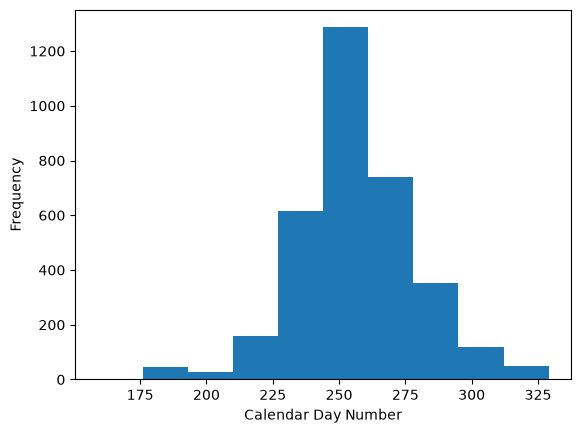

In [29]:
times = severe_df[time_col].map(lambda x: x.timetuple().tm_yday)
times.plot.hist(xlabel="Calendar Day Number")

In [25]:
times.describe()

count    3391.000000
mean      256.027131
std        22.420739
min       159.000000
25%       243.500000
50%       254.000000
75%       270.000000
max       329.000000
Name: ISO_TIME, dtype: float64

In [26]:
def day_count_text(day_count, formatter = '%B %-d'):
  timeline = datetime.datetime(2025, 1, 1) + datetime.timedelta(days = day_count - 1)
  return timeline.strftime(formatter)

In [27]:
# 95% confidence interval
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tstd.html#scipy.stats.tstd
# Calculate statistics like mean and standard deviation
times_mean, times_std = np.mean(times), stats.tstd(times)
print(f"Mean: {round(times_mean)} ({day_count_text(round(times_mean))})")
print(f"Standard Deviation: {round(times_std)} days")

# calculate interval
times_interval = stats.norm.interval(confidence=0.95, loc=times_mean, scale=times_std)
# find start and end of interval and display
times_ci_start = round(times_interval[0])
times_ci_end = round(times_interval[1])
print(f"95% Confidence Interval: {day_count_text(times_ci_start)} to {day_count_text(times_ci_end)}")


Mean: 256 (September 13)
Standard Deviation: 22 days
95% Confidence Interval: July 31 to October 27


In [28]:
lower_bound = 152 # June 1st
upper_bound = 334 # November 30th
scale = upper_bound - lower_bound

# Perform the Kolmogorov-Smirnov test:
# The 'uniform' string or stats.uniform(loc=lower_bound, scale=scale).cdf can be used
statistic, p_value = stats.kstest(times, 'uniform', args=(lower_bound, scale))

print(f"KS Statistic: {statistic}")
print(f"P-value: {p_value}")

# Interpret the results:
# A high p-value (typically > 0.05) suggests that you cannot reject the null hypothesis
# that the sample comes from a uniform distribution.
if p_value > 0.05:
    print("The sample appears to be uniformly distributed.")
else:
    print("The sample does not appear to be uniformly distributed.")

KS Statistic: 0.3440749754521503
P-value: 0.0
The sample does not appear to be uniformly distributed.
